# 04 · Model comparison

## Five feature-stage experiments

Same algorithm (XGBoost), same split, same seed, same metrics — **only the feature set changes**:

| exp | feature set | adds |
|---|---|---|
| `basic` | budget, runtime, release-date, language, genre, country | — |
| `production` | + production company (frequency-encoded), company/country counts | +1 group |
| `people` | + cast/crew sizes, producer/writer/composer counts, director (freq) | +1 group |
| `historical` | + leakage-safe prior-release director/company/cast/franchise stats | +1 group |
| `historical_lead` | + first-billed actor prior avg revenue (star power) | +1 feature |
| `advanced` | + keyword count and keyword flags (superhero/sequel/remake/novel/true story) | +1 group |

Then the winning feature set is **frozen** and four algorithms are compared on it.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


In [3]:
from scripts.prepare_dataset import prepare_ml_dataset
from scripts.evaluation import (
    run_experiment, read_experiment_log, compare_algorithms, XGB_PARAMS,
    FEATURE_SETS,
)
from xgboost import XGBRegressor

import matplotlib.ticker as mtick

## 1. Run the five feature-stage experiments

In [4]:
ds = prepare_ml_dataset()

for feature_set in FEATURE_SETS:
    model = XGBRegressor(**XGB_PARAMS)
    res = run_experiment(feature_set, feature_set, ds, model, XGB_PARAMS, notes='incremental feature stage')
    print(f"{feature_set:>10}: test R2={res['test_metrics']['r2']:.3f}  log-RMSE={res['test_metrics']['rmse']:.3f}")

     basic: test R2=0.505  log-RMSE=1.152


production: test R2=0.562  log-RMSE=1.083


    people: test R2=0.567  log-RMSE=1.078


historical: test R2=0.589  log-RMSE=1.049


historical_lead: test R2=0.592  log-RMSE=1.045


  advanced: test R2=0.587  log-RMSE=1.052


In [5]:
log = read_experiment_log()
log[(log['experiment_id'].isin(list(FEATURE_SETS.keys())))][
    ['experiment_id', 'mae', 'rmse', 'r2', 'raw_rmse', 'raw_mae']
].set_index('experiment_id')

,mae,rmse,r2,raw_rmse,raw_mae
experiment_id,,,,,
basic,0.9020,1.1518,0.5052,188219797.0,80820416.0
production,0.8450,1.0831,0.5625,194505734.0,78314324.0
people,0.8524,1.0775,0.5670,198297029.0,78447434.0
historical,0.8166,1.0495,0.5892,179112263.0,72086509.0
historical_lead,0.8130,1.0453,0.5924,183216522.0,71512857.0
advanced,0.8205,1.0520,0.5872,176628132.0,72854493.0


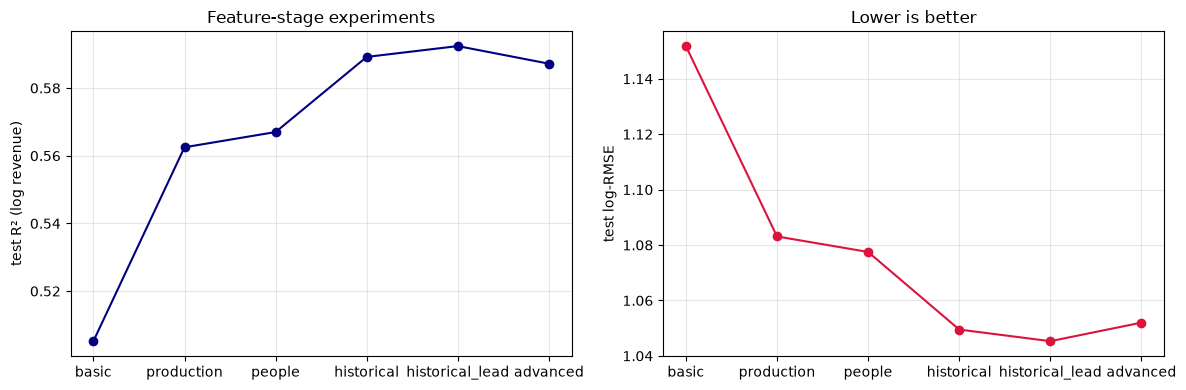

In [6]:
exp = log[log['experiment_id'].isin(list(FEATURE_SETS.keys()))].copy()
order = list(FEATURE_SETS.keys())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(range(len(order)), exp.set_index('experiment_id').loc[order, 'r2'], marker='o', color='navy')
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order)
ax[0].set_ylabel('test R² (log revenue)'); ax[0].set_title('Feature-stage experiments'); ax[0].grid(alpha=0.3)

ax[1].plot(range(len(order)), exp.set_index('experiment_id').loc[order, 'rmse'], marker='o', color='crimson')
ax[1].set_xticks(range(len(order))); ax[1].set_xticklabels(order)
ax[1].set_ylabel('test log-RMSE'); ax[1].set_title('Lower is better'); ax[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'feature_stage_experiments.png', bbox_inches='tight')
plt.show()

## 2. Freeze the best feature set and compare algorithms

In [7]:
best_set = 'historical_lead'
alg_res = compare_algorithms(ds, best_set, notes='algorithm comparison on frozen feature set')
alg_res.set_index('model')

,mae,rmse,r2,raw_rmse,raw_mae
model,,,,,
linear_regression,0.838120,1.063283,0.578331,1.896525e+08,7.596147e+07
random_forest,0.841864,1.076967,0.567408,1.741043e+08,7.401835e+07
xgboost,0.812953,1.045348,0.592436,1.832165e+08,7.151286e+07
lightgbm,0.841593,1.071901,0.571468,1.760893e+08,7.355229e+07


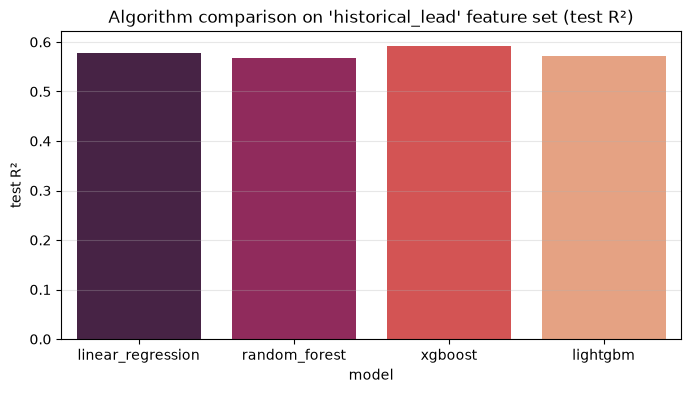

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=alg_res, x='model', y='r2', hue='model', legend=False, palette='rocket', ax=ax)
ax.set_title(f'Algorithm comparison on \'{best_set}\' feature set (test R²)')
ax.set_ylabel('test R²'); ax.grid(axis='y', alpha=0.3)
fig.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'algorithm_comparison.png', bbox_inches='tight')
plt.show()

## 3. Full experiment log

In [9]:
log = read_experiment_log()
log[['experiment_id', 'feature_set', 'model', 'mae', 'rmse', 'r2', 'raw_rmse', 'raw_mae', 'notes']]

,experiment_id,feature_set,model,mae,rmse,r2,raw_rmse,raw_mae,notes
0,naive,naive,median,1.3369,1.6381,-0.0009,273192864.0,109816387.0,baseline: median train log revenue
1,linear_bare,basic_numeric,LinearRegression,0.9524,1.1867,0.4747,226293575.0,86535524.0,"numbers only, no categoricals"
2,xgb_basic,basic,XGBRegressor,0.9020,1.1518,0.5052,188219797.0,80820416.0,initial XGBoost on basic set
3,basic,basic,XGBRegressor,0.9020,1.1518,0.5052,188219797.0,80820416.0,incremental feature stage
4,production,production,XGBRegressor,0.8450,1.0831,0.5625,194505734.0,78314324.0,incremental feature stage
5,people,people,XGBRegressor,0.8524,1.0775,0.5670,198297029.0,78447434.0,incremental feature stage
6,historical,historical,XGBRegressor,0.8166,1.0495,0.5892,179112263.0,72086509.0,incremental feature stage
7,historical_lead,historical_lead,XGBRegressor,0.8130,1.0453,0.5924,183216522.0,71512857.0,incremental feature stage
8,advanced,advanced,XGBRegressor,0.8205,1.0520,0.5872,176628132.0,72854493.0,incremental feature stage
9,alg_linear_regression,historical_lead,linear_regression,0.8381,1.0633,0.5783,189652517.0,75961470.0,algorithm comparison on frozen feature set


## Takeaways

- Every incremental feature group improved out-of-time test R² (the biggest jumps came from *people* and *historical*).
- Adding first-billed *star power* on top of the historical set (`historical_lead`) gave a further small test-R² gain.
- **Historical_lead** was the best feature set, so algorithms were compared on it.
- XGBoost and LightGBM outperform the linear and random-forest baselines on this frozen set.

Remaining work before the final pipeline: `05_error_analysis` (why is the model wrong on which films), then packaging the best config into a reproducible prediction path.